In [1]:
!pip -q install requests pandas tqdm

In [2]:
import os
import requests
import pandas as pd
from tqdm import tqdm

In [3]:
os.makedirs("NASA_POWER_DATA", exist_ok=True)

In [4]:
locations = [

    # Uttarakhand
    ("Dehradun",30.3165,78.0322),
    ("Chamoli",30.4200,79.3200),
    ("Rudraprayag",30.2844,78.9811),
    ("Uttarkashi",30.7290,78.4430),
    ("Pithoragarh",29.5829,80.2182),
    ("Tehri_Garhwal",30.3780,78.4800),
    ("Bageshwar",29.8400,79.7700),

    # Himachal Pradesh
    ("Shimla",31.1048,77.1734),
    ("Kullu",31.9579,77.1095),
    ("Mandi",31.7080,76.9310),
    ("Kangra",32.0998,76.2691),
    ("Chamba",32.5530,76.1258),
    ("Kinnaur",31.5383,78.2667),
    ("Lahaul_Spiti",32.5720,77.0330),

    # Jammu & Kashmir
    ("Srinagar",34.0837,74.7973),
    ("Anantnag",33.7311,75.1540),
    ("Pahalgam",34.0159,75.3180),
    ("Kupwara",34.5260,74.2600),

    # Ladakh
    ("Leh",34.1526,77.5771),
    ("Kargil",34.5539,76.1349),

    # Sikkim
    ("Gangtok",27.3389,88.6065),
    ("Namchi",27.1667,88.3667),
    ("Gyalshing",27.2833,88.2500),

    # Arunachal Pradesh
    ("Itanagar",27.0844,93.6053),
    ("Tawang",27.5861,91.8594),
    ("Ziro",27.6290,93.8280),

    # Meghalaya
    ("Shillong",25.5788,91.8933),
    ("Cherrapunji",25.2700,91.7300),

    # WB
    ("Darjeeling",27.0410,88.2663),
    ("Kalimpong",27.0700,88.4700),

    # Kerala
    ("Wayanad",11.6854,76.1320),
    ("Idukki",9.8500,76.9700),

    # Maharashtra
    ("Mahabaleshwar",17.9237,73.6586),
    ("Satara",17.6805,74.0183)
]

In [5]:
parameters = "PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,WS2M,PS"

for city, lat, lon in tqdm(locations):

    url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"parameters={parameters}"
        "&community=AG"
        f"&latitude={lat}"
        f"&longitude={lon}"
        "&start=20150101"
        "&end=20251231"
        "&format=CSV"
    )

    filename = f"NASA_POWER_DATA/{city}.csv"

    r = requests.get(url)

    with open(filename, "wb") as f:
        f.write(r.content)

print("Download Completed!")

100%|██████████| 34/34 [00:26<00:00,  1.27it/s]

Download Completed!


In [6]:
!zip -r NASA_POWER_DATA.zip NASA_POWER_DATA

  adding: NASA_POWER_DATA/ (stored 0%)
  adding: NASA_POWER_DATA/Kupwara.csv (deflated 64%)
  adding: NASA_POWER_DATA/Cherrapunji.csv (deflated 65%)
  adding: NASA_POWER_DATA/Chamoli.csv (deflated 65%)
  adding: NASA_POWER_DATA/Kargil.csv (deflated 65%)
  adding: NASA_POWER_DATA/Kinnaur.csv (deflated 65%)
  adding: NASA_POWER_DATA/Mandi.csv (deflated 65%)
  adding: NASA_POWER_DATA/Kullu.csv (deflated 65%)
  adding: NASA_POWER_DATA/Shimla.csv (deflated 65%)
  adding: NASA_POWER_DATA/Mahabaleshwar.csv (deflated 65%)
  adding: NASA_POWER_DATA/Satara.csv (deflated 65%)
  adding: NASA_POWER_DATA/Dehradun.csv (deflated 65%)
  adding: NASA_POWER_DATA/Idukki.csv (deflated 66%)
  adding: NASA_POWER_DATA/Rudraprayag.csv (deflated 65%)
  adding: NASA_POWER_DATA/Pithoragarh.csv (deflated 65%)
  adding: NASA_POWER_DATA/Kangra.csv (deflated 65%)
  adding: NASA_POWER_DATA/Lahaul_Spiti.csv (deflated 65%)
  adding: NASA_POWER_DATA/Namchi.csv (deflated 65%)
  adding: NASA_POWER_DATA/Wayanad.csv (deflate

In [7]:
from google.colab import files
files.download("NASA_POWER_DATA.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:

# Cloudburst Prediction Across India

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import shap

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [9]:
import glob

files = glob.glob("/content/NASA_POWER_DATA/*.csv")

print("Total Files:", len(files))

Total Files: 34


In [10]:
def read_nasa(file):

    with open(file, "r") as f:
        lines = f.readlines()

    start = 0

    for i, line in enumerate(lines):

        if line.startswith("YEAR"):
            start = i
            break

    return pd.read_csv(file, skiprows=start)

In [11]:
all_data=[]

for file in files:

    df=read_nasa(file)

    city=os.path.basename(file).replace(".csv","")

    df["City"]=city

    all_data.append(df)

weather=pd.concat(all_data,ignore_index=True)

print(weather.shape)

(136612, 10)


In [12]:
weather.to_csv("Cloudburst_India_Dataset.csv",index=False)

In [13]:
weather.head()

,YEAR,DOY,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,WS2M,PS,City
0,2015,1,0.0,0.65,6.22,-2.96,41.42,1.17,74.99,Kupwara
1,2015,2,0.0,0.98,7.05,-4.15,39.41,1.19,74.88,Kupwara
2,2015,3,0.0,0.16,5.18,-3.14,48.52,1.11,74.65,Kupwara
3,2015,4,0.0,-1.50,2.57,-4.35,48.15,1.04,74.79,Kupwara
4,2015,5,0.0,-0.47,4.80,-4.51,63.15,1.06,74.76,Kupwara


In [14]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136612 entries, 0 to 136611
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   YEAR         136612 non-null  int64  
 1   DOY          136612 non-null  int64  
 2   PRECTOTCORR  136612 non-null  float64
 3   T2M          136612 non-null  float64
 4   T2M_MAX      136612 non-null  float64
 5   T2M_MIN      136612 non-null  float64
 6   RH2M         136612 non-null  float64
 7   WS2M         136612 non-null  float64
 8   PS           136612 non-null  float64
 9   City         136612 non-null  object 
dtypes: float64(7), int64(2), object(1)
memory usage: 10.4+ MB


In [15]:
weather.describe()

,YEAR,DOY,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,WS2M,PS
count,136612.000000,136612.000000,136612.000000,136612.000000,136612.000000,136612.000000,136612.000000,136612.000000,136612.000000
mean,2020.000000,183.136635,4.492459,13.364163,18.720576,8.980383,69.073823,1.456248,79.924349
std,3.162368,105.445615,10.156463,9.858191,9.674322,10.383491,18.919661,0.663759,10.618832
min,2015.000000,1.000000,0.000000,-28.570000,-17.910000,-39.370000,7.200000,0.130000,57.170000
25%,2017.000000,92.000000,0.000000,7.420000,13.160000,2.680000,54.780000,1.090000,69.940000
50%,2020.000000,183.000000,0.280000,14.570000,20.290000,10.230000,72.650000,1.400000,78.880000
75%,2023.000000,274.000000,4.590000,21.560000,25.690000,17.340000,85.630000,1.740000,87.890000
max,2025.000000,366.000000,344.760000,35.120000,43.980000,28.960000,100.000000,8.570000,96.770000


In [16]:
weather.isnull().sum()

,0
YEAR,0
DOY,0
PRECTOTCORR,0
T2M,0
T2M_MAX,0
T2M_MIN,0
RH2M,0
WS2M,0
PS,0
City,0


In [17]:
weather.columns.tolist()

['YEAR',
 'DOY',
 'PRECTOTCORR',
 'T2M',
 'T2M_MAX',
 'T2M_MIN',
 'RH2M',
 'WS2M',
 'PS',
 'City']

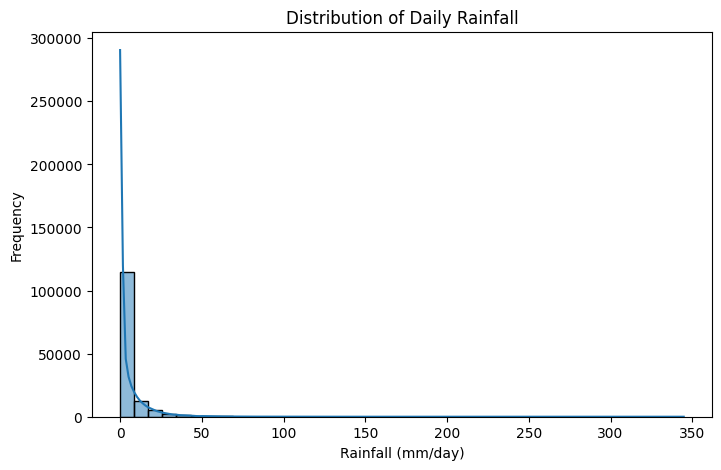

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(weather['PRECTOTCORR'], bins=40, kde=True)

plt.title("Distribution of Daily Rainfall")
plt.xlabel("Rainfall (mm/day)")
plt.ylabel("Frequency")

plt.show()

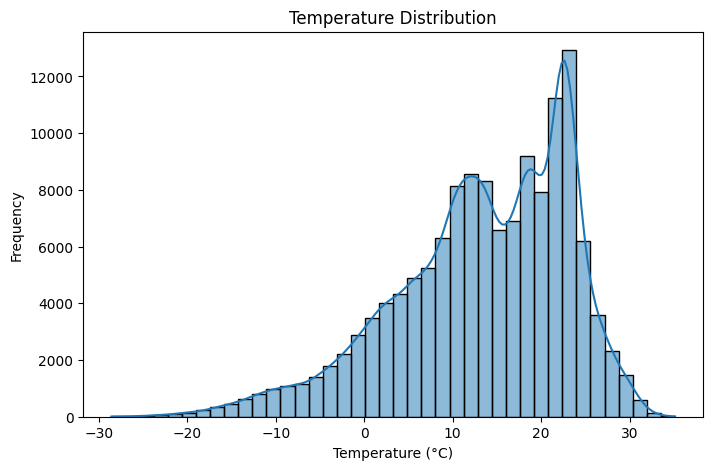

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(weather['T2M'], bins=40, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

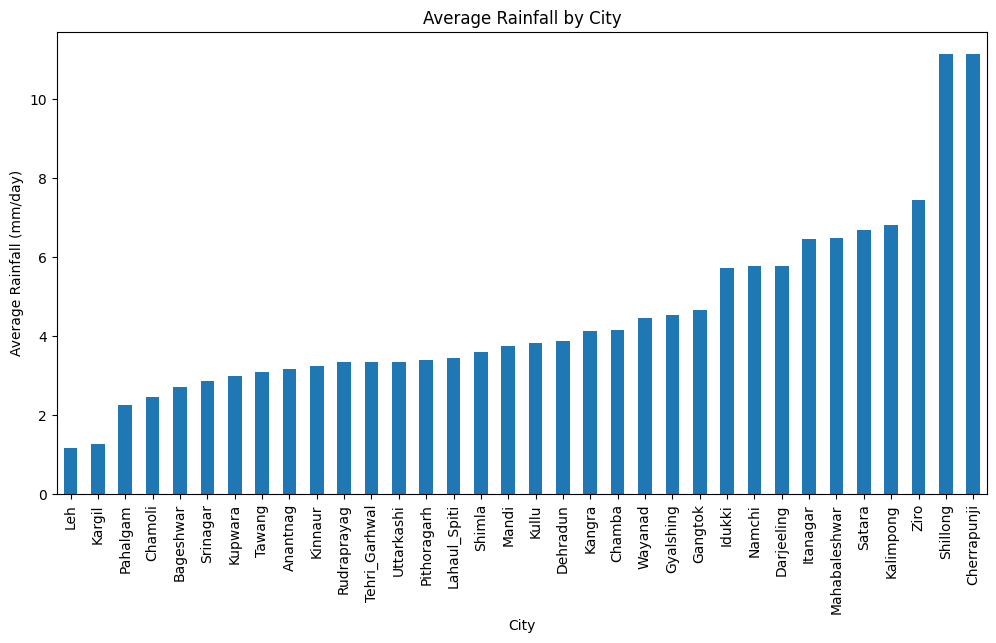

In [20]:
plt.figure(figsize=(12,6))

weather.groupby("City")["PRECTOTCORR"].mean().sort_values().plot(kind="bar")

plt.title("Average Rainfall by City")
plt.xlabel("City")
plt.ylabel("Average Rainfall (mm/day)")

plt.xticks(rotation=90)

plt.show()

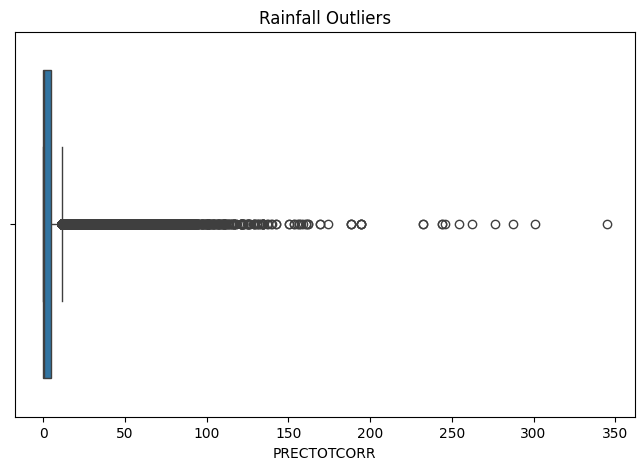

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=weather["PRECTOTCORR"])

plt.title("Rainfall Outliers")

plt.show()

In [22]:
weather["DATE"] = pd.to_datetime(
    weather["YEAR"].astype(str) + weather["DOY"].astype(str),
    format="%Y%j"
)

weather["Month"] = weather["DATE"].dt.month_name()

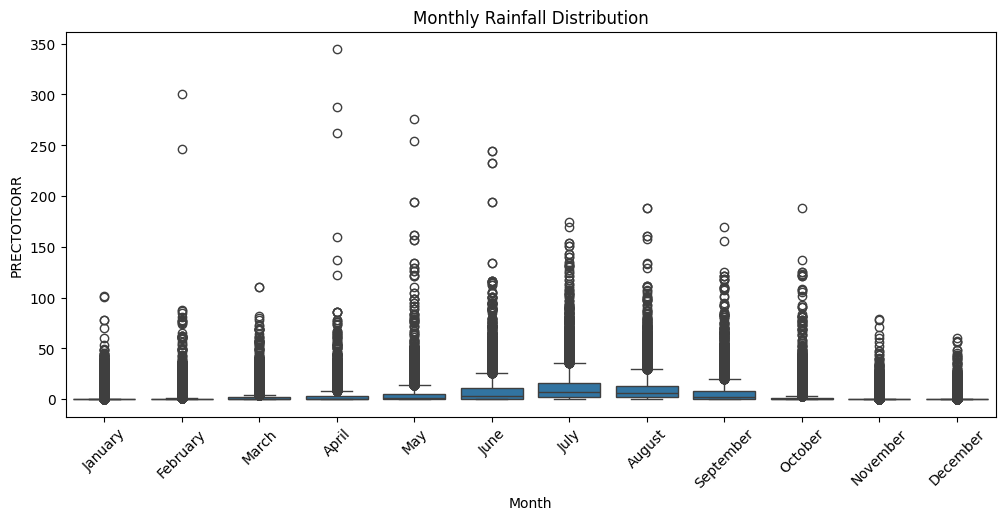

In [23]:
plt.figure(figsize=(12,5))

order = [
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

sns.boxplot(
    x="Month",
    y="PRECTOTCORR",
    data=weather,
    order=order
)

plt.xticks(rotation=45)

plt.title("Monthly Rainfall Distribution")

plt.show()

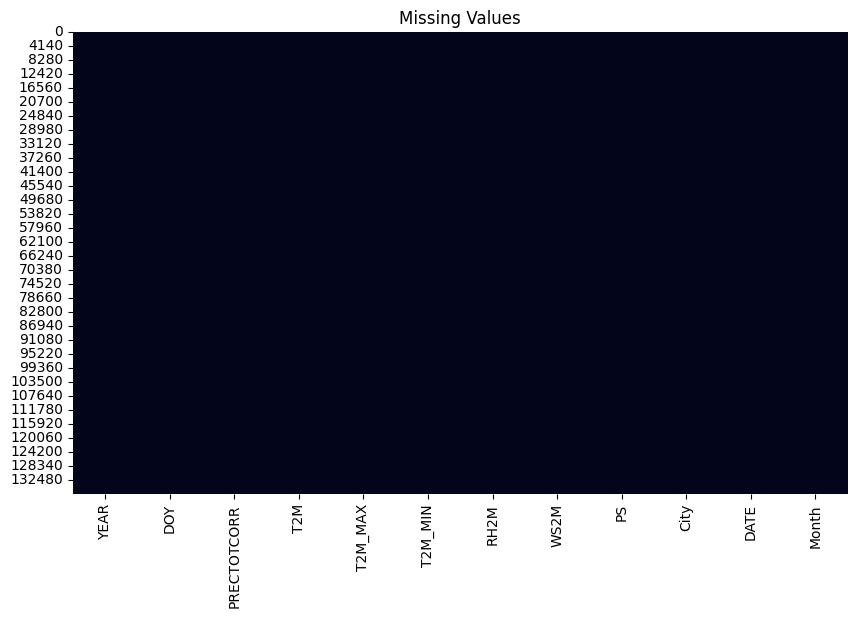

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(weather.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [25]:
weather.columns.tolist()

['YEAR',
 'DOY',
 'PRECTOTCORR',
 'T2M',
 'T2M_MAX',
 'T2M_MIN',
 'RH2M',
 'WS2M',
 'PS',
 'City',
 'DATE',
 'Month']

In [26]:
# Feature Engineering

weather["Temp_Range"] = weather["T2M_MAX"] - weather["T2M_MIN"]

weather["Rain_1_Day"] = weather.groupby("City")["PRECTOTCORR"].shift(1)
weather["Rain_3_Day"] = weather.groupby("City")["PRECTOTCORR"].rolling(3).mean().reset_index(0,drop=True)
weather["Rain_7_Day"] = weather.groupby("City")["PRECTOTCORR"].rolling(7).mean().reset_index(0,drop=True)

weather["Temp_3_Day"] = weather.groupby("City")["T2M"].rolling(3).mean().reset_index(0,drop=True)

weather.fillna(method="bfill", inplace=True)

weather.head()

,YEAR,DOY,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,WS2M,PS,City,DATE,Month,Temp_Range,Rain_1_Day,Rain_3_Day,Rain_7_Day,Temp_3_Day
0,2015,1,0.0,0.65,6.22,-2.96,41.42,1.17,74.99,Kupwara,2015-01-01,January,9.18,0.0,0.0,0.0,0.596667
1,2015,2,0.0,0.98,7.05,-4.15,39.41,1.19,74.88,Kupwara,2015-01-02,January,11.20,0.0,0.0,0.0,0.596667
2,2015,3,0.0,0.16,5.18,-3.14,48.52,1.11,74.65,Kupwara,2015-01-03,January,8.32,0.0,0.0,0.0,0.596667
3,2015,4,0.0,-1.50,2.57,-4.35,48.15,1.04,74.79,Kupwara,2015-01-04,January,6.92,0.0,0.0,0.0,-0.120000
4,2015,5,0.0,-0.47,4.80,-4.51,63.15,1.06,74.76,Kupwara,2015-01-05,January,9.31,0.0,0.0,0.0,-0.603333


In [27]:
# Cloudburst Target
weather["Cloudburst_Event"] = np.where(
    weather["PRECTOTCORR"] >= 100,
    1,
    0
)

weather["Cloudburst_Event"].value_counts()

,count
Cloudburst_Event,
0,136466
1,146


In [28]:
features = [
    "PRECTOTCORR",
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "WS2M",
    "PS",
    "Temp_Range",
    "Rain_1_Day",
    "Rain_3_Day",
    "Rain_7_Day",
    "Temp_3_Day"
]

X = weather[features]

y = weather["Cloudburst_Event"]

print(X.shape)
print(y.shape)

(136612, 12)
(136612,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(109289, 12)
(27323, 12)


In [30]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

print("Accuracy :", accuracy_score(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27294
           1       1.00      1.00      1.00        29

    accuracy                           1.00     27323
   macro avg       1.00      1.00      1.00     27323
weighted avg       1.00      1.00      1.00     27323

Accuracy : 1.0


In [31]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print(classification_report(y_test, xgb_pred))

print("Accuracy :", accuracy_score(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27294
           1       0.84      0.72      0.78        29

    accuracy                           1.00     27323
   macro avg       0.92      0.86      0.89     27323
weighted avg       1.00      1.00      1.00     27323

Accuracy : 0.9995608095743512


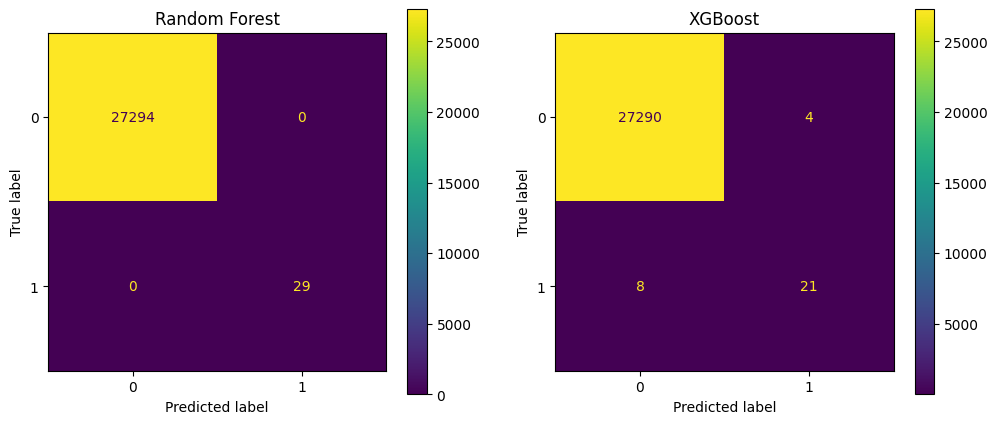

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1,2,figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    ax=ax[0]
)

ax[0].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    ax=ax[1]
)

ax[1].set_title("XGBoost")

plt.show()

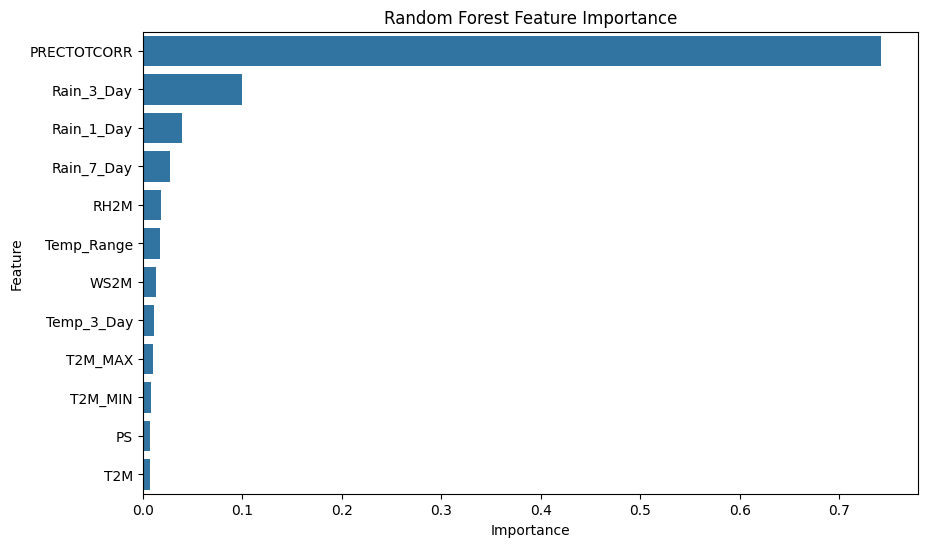

In [33]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [35]:
#shap
explainer = shap.Explainer(rf, X_train)

shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=12)

100%|===================| 54400/54646 [01:39<00:00]       

ValueError: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

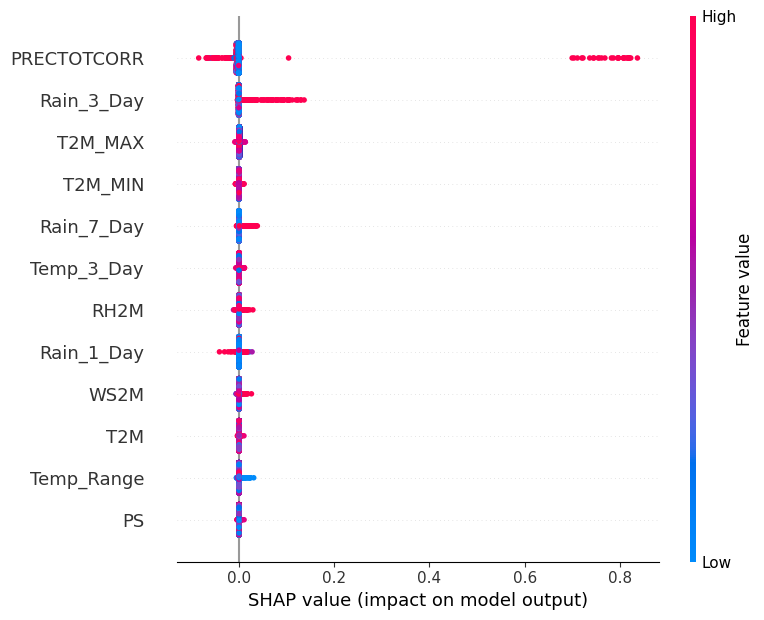

In [36]:
# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

# For newer SHAP versions
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values[:, :, 1], X_test)